In [1]:
from mpmath import mp
import numpy as np
import matplotlib.pyplot as plt

In [11]:
mp.dps = 80  # adjust if needed

In [5]:
def rate_ratio(M, k):
    # NrateRatio[M_, k_] := N[Exp[-3*k/M]];
    return mp.e ** (-3 * mp.mpf(k) / mp.mpf(M))

In [6]:
def pi_N(n, M, k):
    # NpiN[n_, M_, k_] := If[k != 0, (1 - r)/(1 - r^n), 1/n];
    if k != 0:
        r = rate_ratio(M, k)
        return (1 - r) / (1 - r ** n)
    else:
        return mp.mpf(1) / n

In [7]:
def adjacent_dists_KLD(n, M, k):
    # NadjacentDistsKLD[n_, M_, k_] := -Log[pi_N(n,M,k+1)/pi_N(n,M,k)]
    #   + If[k != 0,
    #        3/M * (r - n*r^n + (n-1)*r^(n+1)) / ((1 - r)*(1 - r^n)),
    #        3*(n - 1)/(2*M)
    #     ];
    term1 = -mp.log(pi_N(n, M, k + 1) / pi_N(n, M, k))
    if k != 0:
        r = rate_ratio(M, k)
        num = r - n * (r ** n) + (n - 1) * (r ** (n + 1))
        den = (1 - r) * (1 - r ** n)
        term2 = (3 / mp.mpf(M)) * (num / den)
    else:
        term2 = 3 * (n - 1) / (2 * mp.mpf(M))
    return term1 + term2


In [8]:
def total_ent_prod(n, M):
    # NtotalEntProd[n_, M_] := Sum[adjacent_dists_KLD[n,M,k], {k, -M, M}];
    s = mp.mpf('0')
    for k in range(-int(M), int(M) + 1):
        s += adjacent_dists_KLD(n, M, k)
    return s

In [9]:
def entropy_sum(n, M):
    # EntropySum[n_, M_] := NSum[If[k != 0, ..., 3*(n - 1)/(2*M)], {k, -M, M}]
    s = mp.mpf('0')
    for k in range(-int(M), int(M) + 1):
        if k != 0:
            r = rate_ratio(M, k)
            num = r - n * (r ** n) + (n - 1) * (r ** (n + 1))
            den = (1 - r) * (1 - r ** n)
            term = (3 / mp.mpf(M)) * (num / den)
        else:
            term = 3 * (n - 1) / (2 * mp.mpf(M))
        s += term
    return s

In [10]:
def log_sum(n, M): 
    s = mp.mpf('0') 
    for k in range(-int(M), int(M)+1): 
        s += -mp.log(pi_N(n, M, k + 1) / pi_N(n, M, k))
        
    return s
            

In [15]:
def constant_protocol_formula(n, M): 
    c_delta = 3

    sigma_tot = c_delta/M * (n/(2*mp.tanh(c_delta*n/2)) + 
            mp.exp(c_delta)*(mp.exp(c_delta*(n+1))-mp.exp(-c_delta * n) - mp.exp(c_delta)- 1)/(2*(mp.exp(c_delta)-1)*(1-mp.exp(-c_delta*n))))

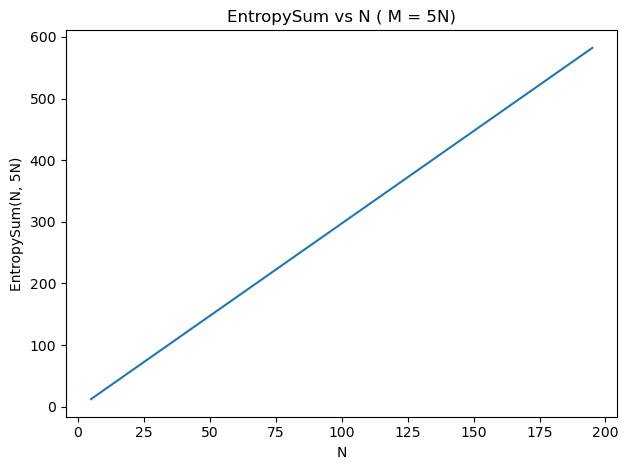

In [9]:
alpha = 5
Ns = list(range(5, 200, 5))
Ys = [entropy_sum(N, alpha*N) for N in Ns]

# Convert to float for plotting
Ys_float = [float(y) for y in Ys]

plt.figure()
plt.plot(Ns, Ys_float)
plt.xlabel("N")
plt.ylabel(f"EntropySum(N, {alpha}N)")
plt.title(f"EntropySum vs N ( M = {alpha}N)")
# If values span orders of magnitude, a log y-scale can help:
# plt.yscale('log')
plt.tight_layout()
plt.show()

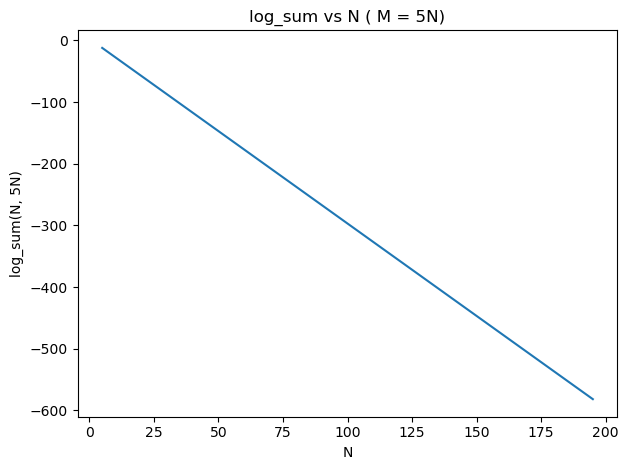

In [10]:
alpha = 5
Ns = list(range(5, 200, 5))
logs = [log_sum(N, alpha*N) for N in Ns]

# Convert to float for plotting
logs_float = [float(y) for y in logs]

plt.figure()
plt.plot(Ns, logs_float)
plt.xlabel("N")
plt.ylabel(f"log_sum(N, {alpha}N)")
plt.title(f"log_sum vs N ( M = {alpha}N)")
# If values span orders of magnitude, a log y-scale can help:
# plt.yscale('log')
plt.tight_layout()
plt.show()

In [11]:
totals = [x[0]+x[1] for x in zip(Ys,logs)]

In [12]:
[float(x) for x in totals]

[0.23409273863579247,
 0.2669533579074775,
 0.2779476428809975,
 0.2834526708772356,
 0.286758244543498,
 0.2889630335320741,
 0.29053841095247407,
 0.29172023380279605,
 0.29263960149889073,
 0.293375204312935,
 0.2939771331084064,
 0.2944787899626371,
 0.29490330404058257,
 0.29526719895492026,
 0.295582593754295,
 0.29585857884336114,
 0.2961021064517036,
 0.2963185843767373,
 0.2965122822869373,
 0.2966866161700126,
 0.29684435153299843,
 0.29698775119901155,
 0.2971186845582323,
 0.2972387095128687,
 0.29734913475998165,
 0.297451067704623,
 0.2975454517279433,
 0.29763309547096706,
 0.2977146960608934,
 0.29779085769305497,
 0.29786210661705637,
 0.29792890331353317,
 0.2979916524573521,
 0.2980507111229073,
 0.2981063955830323,
 0.2981589869749473,
 0.2982087360475518,
 0.2982558671592617,
 0.29830058166088846]

In [13]:
alpha = 10
Ns = list(range(5, 200, 5))
logs2 = [log_sum(N, alpha*N) for N in Ns]

logs2_float = [float(log) for log in logs2]

In [14]:
diff = [x[0]-x[1] for x in zip(logs_float, logs2_float)]
print(diff)

[-0.0028606985559704867, -0.001499312969780675, -0.0010153906510765864, -0.000767562925560128, -0.0006169597694452023, -0.0005157564305591222, -0.00044307371673824036, -0.00038834504056239894, -0.00034564954452775964, -0.0003114118570692881, -0.00028334536332863536, -0.00025991955021709146, -0.0002400713563588397, -0.00022303937319634315, -0.0002082639387595009, -0.00019532447018377752, -0.00018389878886182487, -0.0001737359315256981, -0.00016463750387174514, -0.00015644460114572212, -0.00014902844861808262, -0.00014228358372747607, -0.00013612280923780418, -0.00013047340303273813, -0.00012527423427854956, -0.00012047354243804875, -0.00011602720803693956, -0.00011189739308292701, -0.00010805146149550637, -0.00010446111480177933, -0.000101101694724548, -9.79516162260552e-05, -9.49919029267221e-05, -9.220580483315644e-05, -8.957848103818833e-05, -8.709673522844241e-05, -8.474879416553449e-05, -8.252412055753666e-05, -8.041325543217681e-05]


In [15]:
Ys2 = [entropy_sum(N, alpha*N) for N in Ns]
Ys2_float = [float(y) for y in Ys2] 

In [16]:
diff = [x[0]-x[1] for x in zip(Ys_float, Ys2_float)]
print(diff) 

[0.120000000000001, 0.134999999999998, 0.14000000000000057, 0.1424999999999983, 0.14399999999999125, 0.14500000000001023, 0.14571428571427703, 0.1462500000000091, 0.14666666666664696, 0.14700000000001978, 0.14727272727270702, 0.14749999999997954, 0.14769230769232422, 0.14785714285716267, 0.14799999999999613, 0.14812499999999318, 0.14823529411762593, 0.14833333333336896, 0.14842105263159056, 0.14850000000001273, 0.14857142857141525, 0.14863636363639898, 0.1486956521738989, 0.14875000000000682, 0.14879999999999427, 0.14884615384619337, 0.14888888888884821, 0.14892857142854155, 0.14896551724137908, 0.1490000000000009, 0.14903225806455112, 0.14906250000001364, 0.14909090909094402, 0.14911764705885844, 0.14914285714291964, 0.14916666666658784, 0.149189189189201, 0.14921052631586917, 0.1492307692307122]


In [17]:
Ys3 = [entropy_sum(N, 15*N) for N in Ns]
Ys3_float = [float(y) for y in Ys3] 

In [18]:
diff = [x[0]-x[1] for x in zip(Ys_float, Ys3_float)]
print(diff) 

[0.16000000000000014, 0.17999999999999972, 0.18666666666666742, 0.18999999999999773, 0.19199999999999307, 0.19333333333334224, 0.19428571428571217, 0.1950000000000074, 0.1955555555555577, 0.19599999999999795, 0.1963636363636283, 0.19666666666665833, 0.19692307692307054, 0.1971428571428646, 0.1973333333333187, 0.1974999999999909, 0.19764705882352018, 0.19777777777778738, 0.1978947368421018, 0.19800000000003593, 0.19809523809522034, 0.19818181818180847, 0.1982608695652175, 0.19833333333332348, 0.19839999999999236, 0.19846153846157222, 0.19851851851848323, 0.19857142857142662, 0.1986206896551721, 0.19866666666666788, 0.19870967741934464, 0.1987500000000182, 0.19878787878786852, 0.1988235294117544, 0.1988571428571504, 0.19888888888885958, 0.19891891891893465, 0.1989473684210452, 0.19897435897439664]


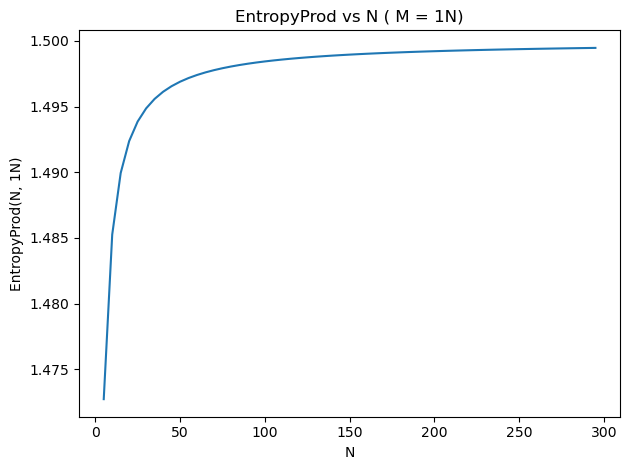

In [19]:
alpha = 1
Ns = list(range(5, 300, 5))
EntProds = [total_ent_prod(N, alpha*(N-1)) for N in Ns]

# Convert to float for plotting
EntProds_float = [float(y) for y in EntProds]

plt.figure()
plt.plot(Ns, EntProds_float)
plt.xlabel("N")
plt.ylabel(f"EntropyProd(N, {alpha}N)")
plt.title(f"EntropyProd vs N ( M = {alpha}N)")
# If values span orders of magnitude, a log y-scale can help:
# plt.yscale('log')
plt.tight_layout()
plt.show()

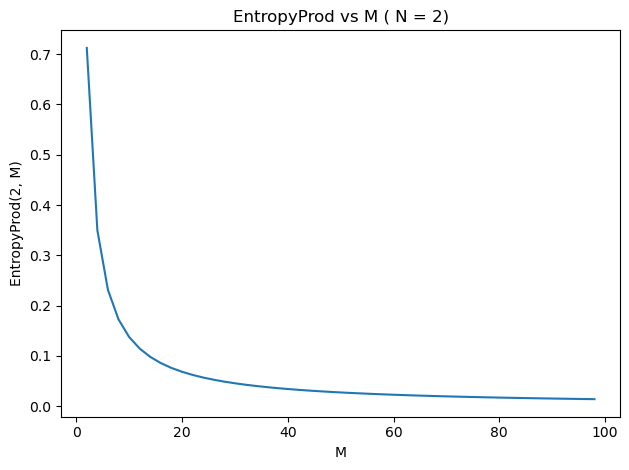

In [20]:

Ms = list(range(2, 100, 2))
EntProds = [total_ent_prod(2, M) for M in Ms]

# Convert to float for plotting
EntProds_float = [float(y) for y in EntProds]

plt.figure()
plt.plot(Ms, EntProds_float)
plt.xlabel("M")
plt.ylabel(f"EntropyProd(2, M)")
plt.title(f"EntropyProd vs M ( N = 2)")
# If values span orders of magnitude, a log y-scale can help:
# plt.yscale('log')
plt.tight_layout()
plt.show()

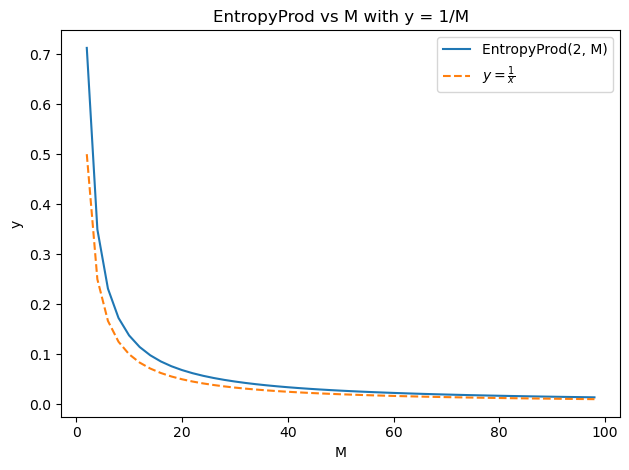

In [21]:
Ms = list(range(2, 100, 2))
EntProds = [total_ent_prod(2, M) for M in Ms]

# Convert to float for plotting
EntProds_float = [float(y) for y in EntProds]

# Function y = 1/x
inv_values = [1 / M for M in Ms]

plt.figure()
plt.plot(Ms, EntProds_float, label="EntropyProd(2, M)")
plt.plot(Ms, inv_values, label=r"$y = \frac{1}{x}$", linestyle="--")

plt.xlabel("M")
plt.ylabel("y")
plt.title("EntropyProd vs M with y = 1/M")
plt.legend()
# plt.yscale('log')  # Uncomment if orders of magnitude differ significantly
plt.tight_layout()
plt.show()

In [22]:
float(100*total_ent_prod(2, 10))

13.763190729691722

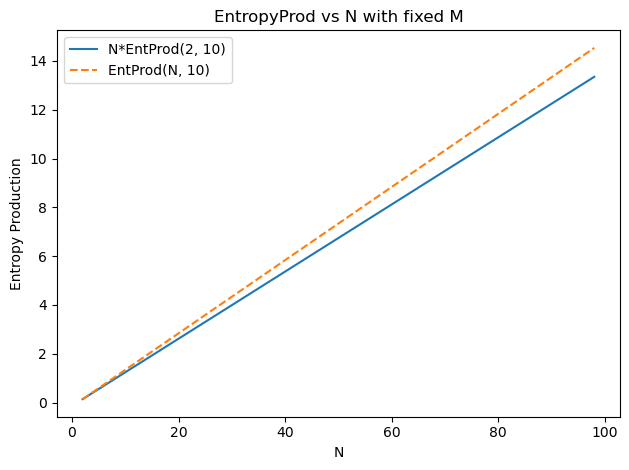

In [51]:
Ns = list(range(2, 100, 2))
EntProdSteps = [(N-1)*total_ent_prod(2,10) for N in Ns] 
EntProdIncrement = [total_ent_prod(N, 10) for N in Ns] 

EntProdSteps_float = [ float(y) for y in EntProdSteps]
EntProdIncrement_float = [ float(y) for y in EntProdIncrement]

plt.figure()
plt.plot(Ns, EntProdSteps_float, label="N*EntProd(2, 10)")
plt.plot(Ns, EntProdIncrement_float, label=r"EntProd(N, 10)", linestyle="--")

plt.xlabel("N")
plt.ylabel("Entropy Production")
plt.title("EntropyProd vs N with fixed M")
plt.legend()
# plt.yscale('log')  # Uncomment if orders of magnitude differ significantly
plt.tight_layout()
plt.show()

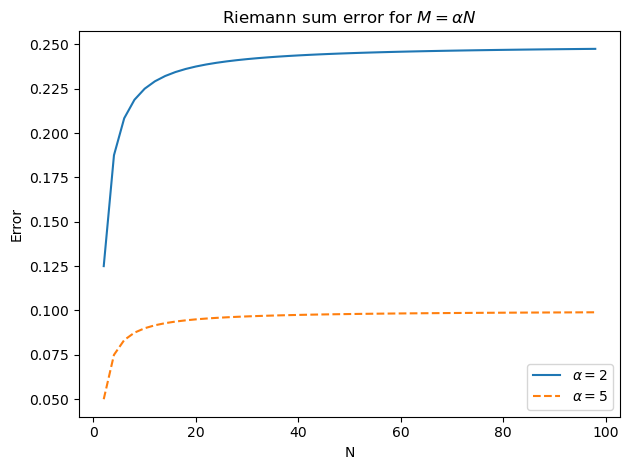

In [41]:
Ns = list(range(2, 100, 2))
Errs = [1/3*entropy_sum(N,2*N)-(N-1) for N in Ns] 
Errs_float = [float(y) for y in Errs]

Errs2 = [1/3*entropy_sum(N,5*N)-(N-1) for N in Ns] 
Errs2_float = [float(y) for y in Errs2]
plt.figure()
plt.plot(Ns, Errs_float, label=r"$\alpha = 2$")
plt.plot(Ns, Errs2_float, label=r"$\alpha = 5$", linestyle="--")

plt.xlabel("N")
plt.ylabel("Error")
plt.title(r"Riemann sum error for $M=\alpha N$")
plt.legend()
# plt.yscale('log')  # Uncomment if orders of magnitude differ significantly
plt.tight_layout()
plt.show()

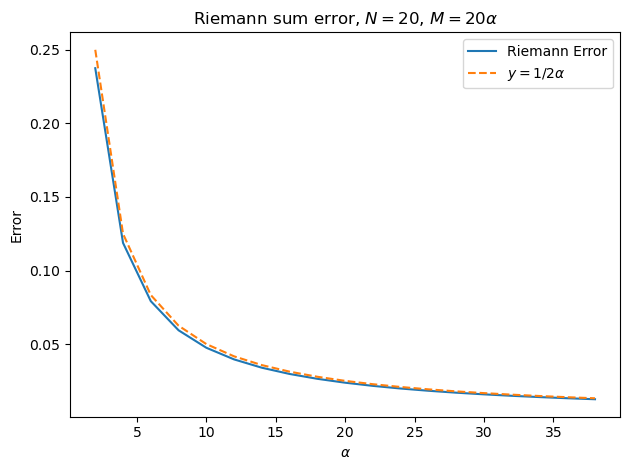

In [54]:
alphas = list(range(2, 40,2))
Errs = [1/3*entropy_sum(20,alpha*20)-(20-1) for alpha in alphas] 
Errs_float = [float(y) for y in Errs]

inv2_vals = [1/(2*alpha) for alpha in alphas]
plt.figure()
plt.plot(alphas, Errs_float, label=r"Riemann Error")
plt.plot(alphas, inv2_vals, label=r"$y = 1/2\alpha$", linestyle="--")

plt.xlabel(r"$\alpha$")
plt.ylabel("Error")
plt.title(r"Riemann sum error, $N=20$, $M=20\alpha$")
plt.legend()
# plt.yscale('log')  # Uncomment if orders of magnitude differ significantly
plt.tight_layout()
plt.show()

In [4]:
from numpy.dtypes import ObjectDType
from EnergyProtocolOptimization import *

In [5]:
delta = np.exp(-3)
Cdelta = -np.log(delta)
n = 10


optimal_protocols_n10 = np.array(
    np.load(
        "/home/farid/Documents/NonGitCode/ComputationalEntropy/optimalProtocol_10_5_100_5.npy",
        allow_pickle=True,
    ),
    dtype=ObjectDType,
)

optimal_protocols_n20 = np.asarray( 
    np.load(
        "/home/farid/Documents/NonGitCode/ComputationalEntropy/optimalProtocol_20_5_100_5.npy", 
        allow_pickle=True,
    ), 
    dtype=ObjectDType, 
) 

In [53]:
min_increment_n10 = np.asarray([np.min(protocol) for protocol in optimal_protocols_n10])
min_increment_n20 = np.asarray([np.min(protocol) for protocol in optimal_protocols_n20])

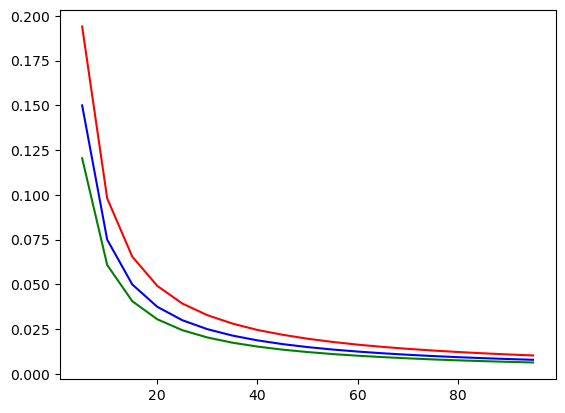

In [54]:
x = np.linspace(5, 100, 20)
inverseM_curve = np.asarray([-np.log(delta) /(4*i) for i in range(5, 100, 5)])
plt.plot(x[:-1], min_increment_n10, color="red")
plt.plot(x[:-1], min_increment_n20, color="green")
plt.plot(x[:-1], inverseM_curve, color="blue")

plt.show()

In [59]:
min_cost_n10 = np.load(
    "/home/farid/Documents/NonGitCode/ComputationalEntropy/optimalProtocolCost_10_5_100_5.npy"
)
min_cost_n20 = np.load(
    "/home/farid/Documents/NonGitCode/ComputationalEntropy/optimalProtocolCost_20_5_100_5.npy"
)

#min cost is the Riemann sum, need to subtract the integral C_\delta *(N-1)
min_cost_n10 = min_cost_n10 - 9*Cdelta
min_cost_n20 = min_cost_n20 - 19*Cdelta

constant_protocol_cost_n10 = np.asarray(
    [Cdelta* 10/(2*i)+Cdelta/(2*i) * 10/np.tanh(Cdelta*10) for i in range(5, 100, 5)])
constant_protocol_cost_n20 = np.asarray([Cdelta* 20/(2*i) for i in range(5, 100, 5)])


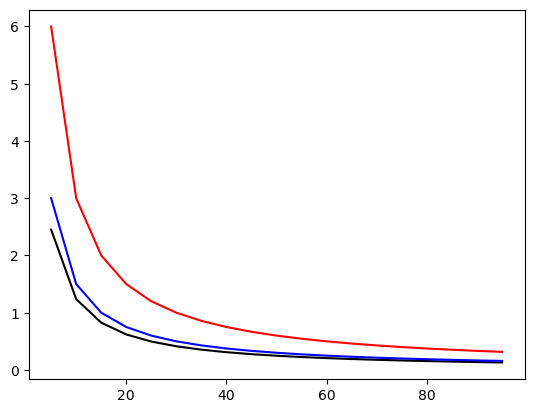

In [56]:

plt.plot(x[:-1], constant_protocol_cost_n20, color='red') 


plt.plot(x[:-1], min_cost_n20[:-1], color='black') 
plt.plot(x[:-1], constant_protocol_cost_n20/2, color='blue') 

plt.show()

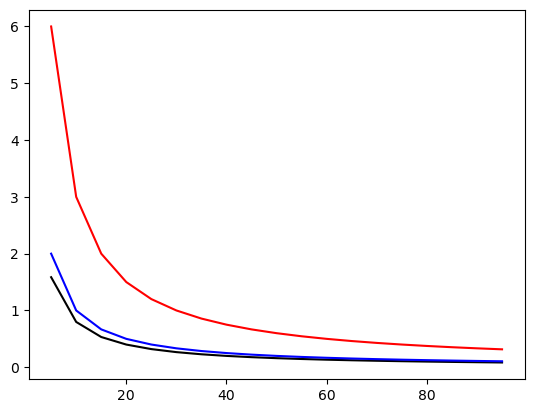

In [61]:


plt.plot(x[:-1], constant_protocol_cost_n10, color='red')
plt.plot(x[:-1], min_cost_n10[:-1], color='black')
plt.plot(x[:-1], constant_protocol_cost_n10/3, color='blue') 

plt.show()

In [6]:
optimal_protocols_n10

array([array([1.83458026, 0.60923119, 0.30873182, 0.21529297, 0.19406272,
              0.21292072, 0.27601398, 0.41425212, 0.6872117 , 1.24770252]),
       array([1.06073041, 0.58847103, 0.38582961, 0.26864423, 0.19572615,
              0.15093425, 0.12411159, 0.10856118, 0.10053746, 0.0980523 ,
              0.10045468, 0.10785781, 0.12133699, 0.14284303, 0.17553585,
              0.22399232, 0.29412274, 0.39473885, 0.54892405, 0.80859546]),
       array([0.73984438, 0.49266241, 0.36115635, 0.27500705, 0.21650598,
              0.17292914, 0.14082612, 0.11712176, 0.09988033, 0.08743423,
              0.07859439, 0.07245844, 0.06846432, 0.06623775, 0.06553223,
              0.06624377, 0.06841172, 0.07215679, 0.07775837, 0.08564226,
              0.09632799, 0.11050095, 0.12914358, 0.15359882, 0.18501415,
              0.22536533, 0.27776274, 0.34953271, 0.44722327, 0.60066266]),
       array([0.56698778, 0.41635128, 0.32235823, 0.26098483, 0.21309265,
              0.17844369, 0.1499

<BarContainer object of 10 artists>

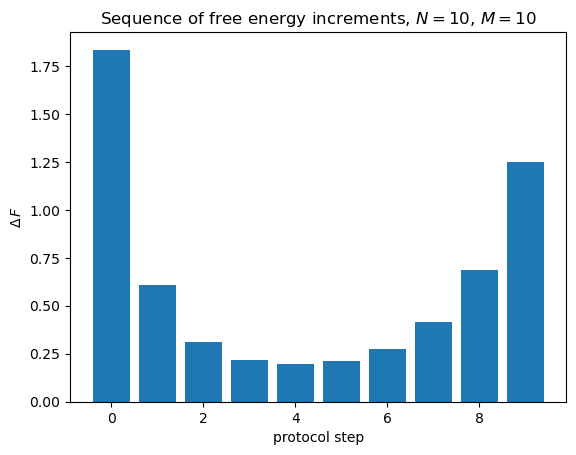

In [18]:
plt.figure()
plt.xlabel(r"protocol step")
plt.ylabel(r"$\Delta\, F$")
plt.title(r"Sequence of free energy increments, $N=10$, $M=10$")
plt.bar(list(range(10)), optimal_protocols_n10[0], label="Sequence of free energy increments")

<BarContainer object of 20 artists>

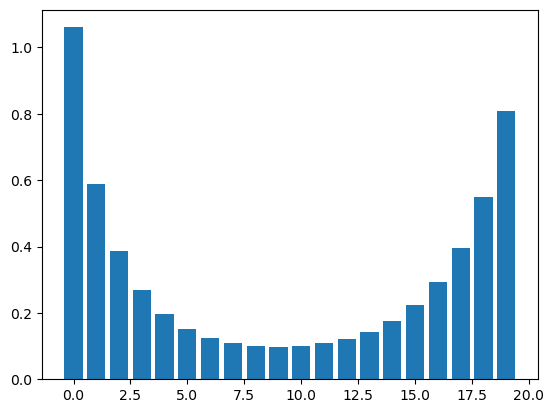

In [9]:
plt.bar(list(range(20)), optimal_protocols_n10[1])

In [9]:
upper_solutions_ls = np.loadtxt("ExactEquationUpperSolutions.csv")
lower_solutions_ls = np.loadtxt("ExactEquationLowerSolutions.csv")
upper_bound_ls = np.asarray([4*(1+mp.log(n))/n for n in range(5, 301)])

x_range = list(range(5,301))

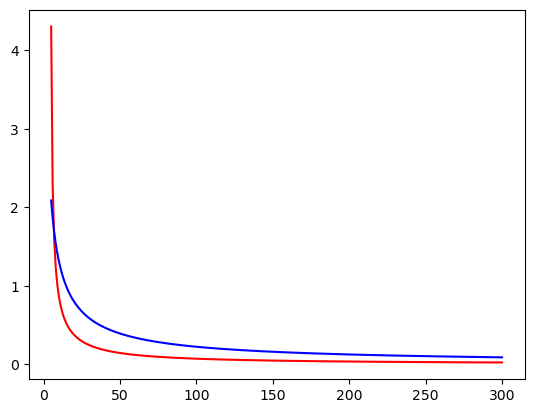

In [10]:
plt.plot(x_range, upper_solutions_ls-lower_solutions_ls, color='red')
plt.plot(x_range, upper_bound_ls, color='blue')
